In [1]:
#two body problem example

#not working for first order. not even with large thrust...(for 1 rev)

#need to find out why 

#will try the one step problem 
using Pkg
Pkg.activate(".")
using LinearAlgebra
using ForwardDiff
using Plots 
using TSSOS 
using DynamicPolynomials
using DifferentialEquations  

  Activating project at `~/Research/polynomial_opt`


In [2]:
#gravitational parameter for the Earth 
μ = 3.986004418e5 #km3/s2

398600.4418

In [3]:
#iss initial conditions
#r0 = [6791.0; 0; 0] #km
#v0 = [0; cosd(51.5)*7.66; sind(51.5)*7.66] #km/s

#new not zero
r0 = [6791.0; 0.01; 0.01] #km
v0 = [0.1; cosd(51.5)*7.66; sind(51.5)*7.66] #km/s

x_initial = [r0; v0]

6-element Vector{Float64}:
 6791.0
    0.01
    0.01
    0.1
    4.768462116644166
    5.994778481489491

In [4]:
#one iss period is around 90-93 minutes
#revs = 5

#working for 1/4 rev...
#suboptimality gap of 21% 
#revs = 1

#finding the period
r_initial = norm(r0)

#finding the period for 1 rev
iss_period = 2*pi*sqrt(r_initial^3/μ)

#period = revs*iss_period 

5569.440597301129

In [5]:
#amount of knot points per orbit 
knot_pts = 2

2

In [6]:
#total number of knot points
#N=knot_pts*revs

N = 2

#when revs is less than 1
#N = knot_pts

2

In [7]:
#define a timestep
#h = period/(N-1) 

#user defined timestep of 1 second 
h = 1 

#here set period to 1, to simulate 1 timestep 
period =1 

1

In [8]:
function two_body_dynamics(x)

    q = x[1:3]
    v = x[4:6]

    a = zeros(eltype(x), size(x))

    r = norm(q)
    
    a[1:3] = v

    a[4:6] = (-μ/r^3)*q

    return a

end

two_body_dynamics (generic function with 1 method)

In [9]:
function rk4_integrator(x)


    f1 = two_body_dynamics(x)
    f2 = two_body_dynamics(x+0.5*h*f1)
    f3 = two_body_dynamics(x+0.5*h*f2)
    f4 = two_body_dynamics(x+h*f3)

    xnext = x + (h/6.0)*(f1+2*f2+2*f3+f4)

    return xnext 

end

rk4_integrator (generic function with 1 method)

In [10]:
#integrate with symplectic euler to see what happens 

In [11]:
#semi implicit euler 

#input is state at timestep k 
#x = [qk, vk]

function symplectic_euler(x)

    #the q and the v are already scaled 

    #qk
    q = x[1:3]

    #vk
    v = x[4:6]

    #next timestep
    xnext = zeros(6)

    ak = (-μ/(norm(q)^3))*q

    #explicit euler on the velocities
    #vk1
    xnext[4:6] = v + h*ak

    #implicit euler on the positions
    #qk1
    xnext[1:3] = q + h*xnext[4:6]

    #xnext = [xk1, vk1] (state at timestep k+1)
    return xnext 

end

symplectic_euler (generic function with 1 method)

In [12]:
#integrate the orbit with symplectic euler to see if the orbit closes

xtraj = zeros(6, N)

xtraj[:,1] = x_initial

6-element Vector{Float64}:
 6791.0
    0.01
    0.01
    0.1
    4.768462116644166
    5.994778481489491

In [13]:
for i=1:N-1

    xtraj[:,i+1] = symplectic_euler(xtraj[:,i])

end

In [14]:
xtraj 

6×2 Matrix{Float64}:
 6791.0      6791.09
    0.01        4.77846
    0.01        6.00478
    0.1         0.0913569
    4.76846     4.76846
    5.99478     5.99478

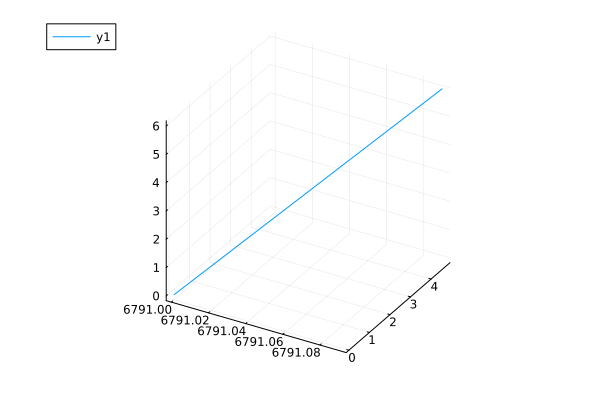

In [15]:
plot(xtraj[1,:], xtraj[2,:], xtraj[3,:])

In [16]:
#not completely periodic. off in the y and the z be 10's of km

In [17]:
#integrate with rk4 to see how much better it is compared to symplectic euler
x_traj_rk4 = zeros(6, N)

6×2 Matrix{Float64}:
 0.0  0.0
 0.0  0.0
 0.0  0.0
 0.0  0.0
 0.0  0.0
 0.0  0.0

In [18]:
x_traj_rk4[:,1] = x_initial 

6-element Vector{Float64}:
 6791.0
    0.01
    0.01
    0.1
    4.768462116644166
    5.994778481489491

In [19]:
for i = 1:N-1

    x_traj_rk4[:,i+1] = rk4_integrator(x_traj_rk4[:,i])

end

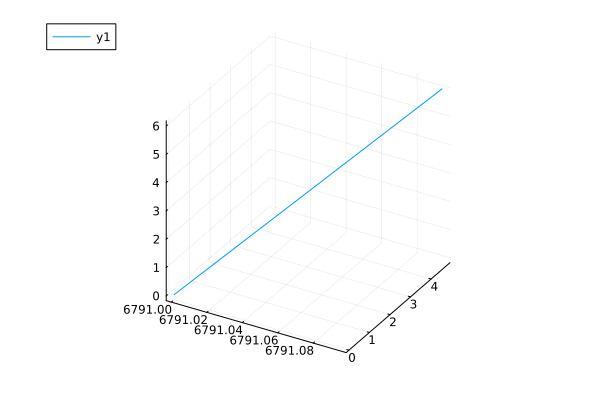

In [20]:
plot(x_traj_rk4[1,:], x_traj_rk4[2,:], x_traj_rk4[3,:])

In [21]:
#difference between the symplectic euler and rk4 final positions after 5 rev sim
x_traj_rk4[:,end] - xtraj[:,end] 

6-element Vector{Float64}:
  0.004321600623370614
 -1.0051087437901174e-6
 -1.2652314502759054e-6
  1.2913291488891865e-7
 -3.0343945285338236e-6
 -3.814756817988041e-6

In [22]:
function two_body_dynamics_form!(du, u, p, t)

    du[1:6] = two_body_dynamics(u[1:6])

end

two_body_dynamics_form! (generic function with 1 method)

In [23]:
#rk78 integrator using DifferentialEquations.jl
function two_body_dynamics_integrate(x_0, period)

    tspan = (0.0, period)
    prob = ODEProblem(two_body_dynamics_form!, x_0, tspan)
    sol = solve(prob, TsitPap8(), abstol=1e-12, reltol=1e-12)


    return sol 
end

two_body_dynamics_integrate (generic function with 1 method)

In [24]:
function get_state(solution)
    
    N = size(solution.u)[1]

    all_states = zeros(6, N)

    for i=1:N
        all_states[:,i] = solution.u[i][1:6]
    end
    
    #all states and all stm are functions of t
    #solution.t is the time
    return all_states
end

get_state (generic function with 1 method)

In [25]:
#use rk78 to integrate the initial condition to 5 revs and check the trajectory 
final_state_sol = two_body_dynamics_integrate(x_initial, period)

retcode: Success
Interpolation: 3rd order Hermite
t: 11-element Vector{Float64}:
 0.0
 0.015439953908207567
 0.0398477609137387
 0.07610927519982019
 0.12633239152251952
 0.19625823097576428
 0.29158355601239777
 0.4240630859151513
 0.6057324495654965
 0.8627795319720022
 1.0
u: 11-element Vector{Vector{Float64}}:
 [6791.0, 0.01, 0.01, 0.1, 4.768462116644166, 5.994778481489491]
 [6791.001542965166, 0.08362483528877972, 0.10255910343791472, 0.09986655072597325, 4.76846211572426, 5.994778480383547]
 [6791.003977914134, 0.2000125382761534, 0.24887849957065622, 0.09965559140370946, 4.768462111318729, 5.994778474924925]
 [6791.007585894389, 0.37292419503278657, 0.46625824461215926, 0.0993421794848223, 4.7684620980979195, 5.994778458422777]
 [6791.012564267725, 0.6124112209392105, 0.7673346995488406, 0.09890809658870989, 4.768462066606491, 5.9947784189970115]
 [6791.019459368713, 0.945849931596227, 1.1865246100110103, 0.09830372236620186, 4.768461997266884, 5.994778332054051]
 [6791.02879093

In [26]:
all_states = get_state(final_state_sol)

6×11 Matrix{Float64}:
 6791.0      6791.0        6791.0        …  6791.08      6791.1
    0.01        0.0836248     0.200013         4.12413      4.77846
    0.01        0.102559      0.248878         5.18217      6.00478
    0.1         0.0998666     0.0996556        0.092543     0.091357
    4.76846     4.76846       4.76846          4.76846      4.76846
    5.99478     5.99478       5.99478    …     5.99478      5.99477

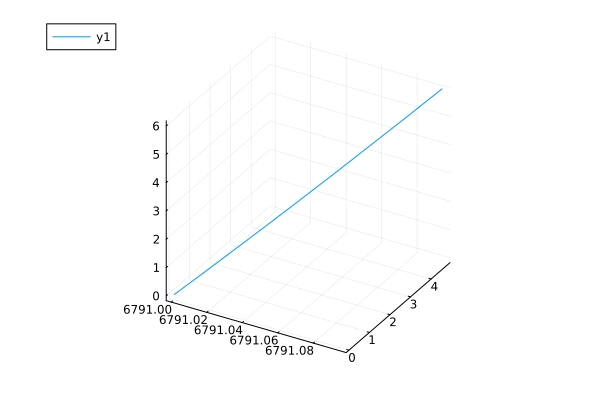

In [27]:
plot(all_states[1,:], all_states[2,:], all_states[3,:]) 

In [28]:
size(all_states)[2]

11

In [29]:
#find a good position and velocity scale 

position_normz = zeros(size(all_states)[2])

velocity_normz = zeros(size(all_states)[2])

for i=1:size(all_states)[2]

    position_normz[i] = norm(all_states[1:3, i])

    velocity_normz[i] = norm(all_states[4:6, i])

end

In [30]:
position_scale = maximum(position_normz) 

#try setting the timescale to scale the period to 1 
#works for the ipopt example 
time_scale = iss_period*5

#scale the maximum velocity to 1
#time_scale = position_scale/maximum(velocity_normz)

velocity_scale = position_scale/time_scale

acceleration_scale = position_scale/time_scale^2

μ_scaled = μ/(position_scale^3/time_scale^2)

h_scaled = h/time_scale

3.591024924422699e-5

In [31]:
time_scale 

27847.202986505647

In [32]:
time_scale 

27847.202986505647

In [33]:
position_scale 

6791.100014384971

In [34]:
#difference between ground truth (rk78) and the two integrators (rk4 and semi implicit euler)

diff_semi_euler = all_states[:,end] - xtraj[:,end]

6-element Vector{Float64}:
  0.004321600623370614
 -1.0051086780649143e-6
 -1.2652313676753124e-6
  1.2913291501381874e-7
 -3.0343945276456452e-6
 -3.814756817988041e-6

In [35]:
diff_rk4 = all_states[:,end] - x_traj_rk4[:,end]

6-element Vector{Float64}:
 0.0
 6.572520305780927e-14
 8.260059303211165e-14
 1.249000902703301e-16
 8.881784197001252e-16
 0.0

In [36]:
#going to try the polynomial optimization 

@polyvar q[1:3, 1:N]
@polyvar v[1:3, 1:N]

@polyvar a[1:3, 1:N]

@polyvar r[1:N]

@polyvar u[1:3,1:N-1]

#this is the slack equal to r^2
@polyvar s[1:N]

#this is the slack equivalent to r^3
@polyvar w[1:N]

(PolyVar{true}[w₁, w₂],)

In [37]:

Qq = Matrix(1.0*I, 3,3)

Qv = Matrix(1.0*I, 3,3)

3×3 Matrix{Float64}:
 1.0  0.0  0.0
 0.0  1.0  0.0
 0.0  0.0  1.0

In [38]:
x_initial 

6-element Vector{Float64}:
 6791.0
    0.01
    0.01
    0.1
    4.768462116644166
    5.994778481489491

In [39]:
#set in kiloNewtons (kN)

#this is what we want... but it doens't solve with large horizons, and small horizons solves with a suboptimality gap ~20%
#umax = 20e-9


#larger control authority makes the suboptimality gap smaller...
#currently 7%
umax = 20e-9

#in scaled units 
umax_bound = umax/acceleration_scale

0.0022837735051141885

In [40]:
#found visually from the unconstrained control case
#this is in the scaled units 

#with the acceleration scale, this corresponds to a maximum of 0.4 N 
#this works 
#u_max_bound = 0.05



#testing 
#doesn't work. maybe not bounding the control space enough 
#u_max_bound = 1/acceleration_scale

In [41]:
#cost function 

f=0

#decreasae the semi major axis
for i=2

    #f+= 1.0*r[i]

    #
    f += 1.0*(r[i])^2

end


#add a cost on controls? (maybe), but it would avoid the bang-bang solution we want 
#introduce a cost or constraint or both

#for i=1:N-1

    #kinda works

    #    f += u[:,i]'*u[:,i]
#end


In [42]:
#initialize equality and inequality constraints 
eq = []
ineq = []

Any[]

In [43]:
x_initial 

6-element Vector{Float64}:
 6791.0
    0.01
    0.01
    0.1
    4.768462116644166
    5.994778481489491

In [44]:
x_initial_scaled = [x_initial[1:3]/position_scale; x_initial[4:6]/velocity_scale]

6-element Vector{Float64}:
  0.9999852727268397
  1.472515495106523e-6
  1.472515495106523e-6
  0.4100543789300621
 19.553287716920526
 24.58185167050474

In [45]:
a_initial_scaled = (-μ_scaled/(norm(x_initial_scaled[1:3])^3))*x_initial_scaled[1:3] 

3-element Vector{Float64}:
 -986.9459048729365
   -0.0014533145411175623
   -0.0014533145411175623

In [46]:
initial_r_scaled = norm(x_initial_scaled[1:3])

initial_s_scaled = initial_r_scaled^2

initial_w_scaled = initial_r_scaled^3

0.9999558188376981

In [47]:
#set the initial condition constraints
append!(eq, [q[1,1] - x_initial_scaled[1]])
append!(eq, [q[2,1] - x_initial_scaled[2]])
append!(eq, [q[3,1] - x_initial_scaled[3]])

append!(eq, [v[1,1] - x_initial_scaled[4]])
append!(eq, [v[2,1] - x_initial_scaled[5]])
append!(eq, [v[3,1] - x_initial_scaled[6]])

append!(eq, [a[1,1] - a_initial_scaled[1]])
append!(eq, [a[2,1] - a_initial_scaled[2]])
append!(eq, [a[3,1] - a_initial_scaled[3]])

#we can also solve for the initial a and set it

#set the initial slacks 

append!(eq, [r[1] - initial_r_scaled])

append!(eq, [s[1] - initial_s_scaled])

append!(eq, [w[1] - initial_w_scaled])

12-element Vector{Any}:
 q₁₋₁ - 0.9999852727268397
 q₂₋₁ - 1.472515495106523e-6
 q₃₋₁ - 1.472515495106523e-6
 v₁₋₁ - 0.4100543789300621
 v₂₋₁ - 19.553287716920526
 v₃₋₁ - 24.58185167050474
 a₁₋₁ + 986.9459048729365
 a₂₋₁ + 0.0014533145411175623
 a₃₋₁ + 0.0014533145411175623
 r₁ - 0.999985272729008
 s₁ - 0.9999705456749084
 w₁ - 0.9999558188376981

In [48]:
#scaling all the units

In [49]:
#set the dynamics constraint between each timestep 

for i=1:N

    #acceleration constraint
    # (old constraint)
    #append!(eq, a[:,i]*r[i]^3 + μ_scaled*q[:,i])

    #slack for r^2
    append!(eq, [s[i] - r[i]^2])

    #slack for r^3
    append!(eq, [w[i] - s[i]*r[i]])

    append!(eq, a[:,i]*w[i] + μ_scaled*q[:,i])

    #slack r constraint 
    append!(eq, [r[i]^2 - q[:,i]'*q[:,i]])

    #try this
    append!(eq, [s[i] - q[:,i]'*q[:,i]])

end

In [50]:
#set a constraint on the r's
for i=1:N

    #lower bound on r that we want to reach 
    append!(ineq, [r[i]-0.75])

    append!(ineq, [2.5 - r[i]])

    #r is always positive (redundant constraint)
    #append!(ineq, [r[i]])

    #set upper and lower bounds on acceleration
    #100 and -100 made up 
    # append!(ineq, [a[1, i]+100])
    # append!(ineq, [a[2, i]+100])
    # append!(ineq, [a[3, i]+100])

    # append!(ineq, [100- a[1,i]])
    # append!(ineq, [100- a[2,i]])
    # append!(ineq, [100- a[2,i]])


    #bound constraints on s and w 
    # append!(ineq, [s[i]+10])
    # append!(ineq, [10- s[i]])

    # append!(ineq, [w[i]+100])
    # append!(ineq, [100 - w[i]])


    #slacks are always positive as well 
    #append!(ineq, [s[i]])

    #append!(ineq, [w[i]])

end

In [51]:
#two types of control constraints. bound constraint 
# and norm constraint (socp constraint). 
#not sure if it can be handeled without squaring it and making it a polynomial 

#bound constraint 
#comment out for now 
for i=1:N-1

    #append!(ineq, norm(u_max_bound - u[1,i], 1))
    #maybe it can't handle the norm?
    #append!(ineq, norm(u[1,i] - u_max_bound, 1))


    #bound constraints
    #order 1 polynomial 
    #two inequalities to represent the absolute value 
    #g(x) >= 0
    append!(ineq, [umax_bound - u[1,i]])
    append!(ineq, [u[1,i] + umax_bound])

    append!(ineq, [umax_bound - u[2,i]])
    append!(ineq, [u[2,i] + umax_bound])

    append!(ineq, [umax_bound - u[3,i]])
    append!(ineq, [u[3,i] + umax_bound])


end

In [52]:
#check all the inequality constraints
ineq 

10-element Vector{Any}:
 r₁ - 0.75
 -r₁ + 2.5
 r₂ - 0.75
 -r₂ + 2.5
 -u₁₋₁ + 0.0022837735051141885
 u₁₋₁ + 0.0022837735051141885
 -u₂₋₁ + 0.0022837735051141885
 u₂₋₁ + 0.0022837735051141885
 -u₃₋₁ + 0.0022837735051141885
 u₃₋₁ + 0.0022837735051141885

In [53]:
#add a control constraint. square the socp constraint to make it a polynomial

#leaving out for now..
# for i=1:N-1

#     append!(ineq, umax_scaled^2 - u[:,i]'*u[:,i])

# end

In [54]:
#check equality constraints
eq 

26-element Vector{Any}:
 q₁₋₁ - 0.9999852727268397
 q₂₋₁ - 1.472515495106523e-6
 q₃₋₁ - 1.472515495106523e-6
 v₁₋₁ - 0.4100543789300621
 v₂₋₁ - 19.553287716920526
 v₃₋₁ - 24.58185167050474
 a₁₋₁ + 986.9459048729365
 a₂₋₁ + 0.0014533145411175623
 a₃₋₁ + 0.0014533145411175623
 r₁ - 0.999985272729008
 ⋮
 -q₁₋₁² - q₂₋₁² - q₃₋₁² + r₁²
 -q₁₋₁² - q₂₋₁² - q₃₋₁² + s₁
 -r₂² + s₂
 -r₂s₂ + w₂
 a₁₋₂w₂ + 986.9168350495464q₁₋₂
 a₂₋₂w₂ + 986.9168350495464q₂₋₂
 a₃₋₂w₂ + 986.9168350495464q₃₋₂
 -q₁₋₂² - q₂₋₂² - q₃₋₂² + r₂²
 -q₁₋₂² - q₂₋₂² - q₃₋₂² + s₂

In [55]:
#assuming mass is 1

In [56]:
for i=1:N-1

    #velocity dynamics constraint
    #added a control  
    append!(eq, v[:,i+1] - (v[:,i] + h_scaled*(a[:,i] + u[:,i])))

    #position dynamics constraint 
    append!(eq, q[:,i+1] - (q[:,i] + h_scaled*v[:,i+1]))

end

In [57]:
#add the inequality constraint
pop = append!([f], ineq)

#add the equality constraint
pop = append!(pop, eq)

43-element Vector{Polynomial{true, Float64}}:
 r₂²
 r₁ - 0.75
 -r₁ + 2.5
 r₂ - 0.75
 -r₂ + 2.5
 -u₁₋₁ + 0.0022837735051141885
 u₁₋₁ + 0.0022837735051141885
 -u₂₋₁ + 0.0022837735051141885
 u₂₋₁ + 0.0022837735051141885
 -u₃₋₁ + 0.0022837735051141885
 ⋮
 a₃₋₂w₂ + 986.9168350495464q₃₋₂
 -q₁₋₂² - q₂₋₂² - q₃₋₂² + r₂²
 -q₁₋₂² - q₂₋₂² - q₃₋₂² + s₂
 -v₁₋₁ + v₁₋₂ - 3.591024924422699e-5a₁₋₁ - 3.591024924422699e-5u₁₋₁
 -v₂₋₁ + v₂₋₂ - 3.591024924422699e-5a₂₋₁ - 3.591024924422699e-5u₂₋₁
 -v₃₋₁ + v₃₋₂ - 3.591024924422699e-5a₃₋₁ - 3.591024924422699e-5u₃₋₁
 -q₁₋₁ + q₁₋₂ - 3.591024924422699e-5v₁₋₂
 -q₂₋₁ + q₂₋₂ - 3.591024924422699e-5v₂₋₂
 -q₃₋₁ + q₃₋₂ - 3.591024924422699e-5v₃₋₂

In [58]:
eq 

32-element Vector{Any}:
 q₁₋₁ - 0.9999852727268397
 q₂₋₁ - 1.472515495106523e-6
 q₃₋₁ - 1.472515495106523e-6
 v₁₋₁ - 0.4100543789300621
 v₂₋₁ - 19.553287716920526
 v₃₋₁ - 24.58185167050474
 a₁₋₁ + 986.9459048729365
 a₂₋₁ + 0.0014533145411175623
 a₃₋₁ + 0.0014533145411175623
 r₁ - 0.999985272729008
 ⋮
 a₃₋₂w₂ + 986.9168350495464q₃₋₂
 -q₁₋₂² - q₂₋₂² - q₃₋₂² + r₂²
 -q₁₋₂² - q₂₋₂² - q₃₋₂² + s₂
 -v₁₋₁ + v₁₋₂ - 3.591024924422699e-5a₁₋₁ - 3.591024924422699e-5u₁₋₁
 -v₂₋₁ + v₂₋₂ - 3.591024924422699e-5a₂₋₁ - 3.591024924422699e-5u₂₋₁
 -v₃₋₁ + v₃₋₂ - 3.591024924422699e-5a₃₋₁ - 3.591024924422699e-5u₃₋₁
 -q₁₋₁ + q₁₋₂ - 3.591024924422699e-5v₁₋₂
 -q₂₋₁ + q₂₋₂ - 3.591024924422699e-5v₂₋₂
 -q₃₋₁ + q₃₋₂ - 3.591024924422699e-5v₃₋₂

In [59]:
ineq 

10-element Vector{Any}:
 r₁ - 0.75
 -r₁ + 2.5
 r₂ - 0.75
 -r₂ + 2.5
 -u₁₋₁ + 0.0022837735051141885
 u₁₋₁ + 0.0022837735051141885
 -u₂₋₁ + 0.0022837735051141885
 u₂₋₁ + 0.0022837735051141885
 -u₃₋₁ + 0.0022837735051141885
 u₃₋₁ + 0.0022837735051141885

In [60]:
#relaxation order
#originally order 2
#d = 2

#try order 1
d = 1

1

In [61]:
s 

2-element Vector{PolyVar{true}}:
 s₁
 s₂

In [62]:
#concatenate all the variables together 

#added s and w 
var = [vec(q); vec(v); vec(a); r; vec(u); s ; w]

27-element Vector{PolyVar{true}}:
 q₁₋₁
 q₂₋₁
 q₃₋₁
 q₁₋₂
 q₂₋₂
 q₃₋₂
 v₁₋₁
 v₂₋₁
 v₃₋₁
 v₁₋₂
 ⋮
 r₁
 r₂
 u₁₋₁
 u₂₋₁
 u₃₋₁
 s₁
 s₂
 w₁
 w₂

In [63]:
x_initial_scaled

6-element Vector{Float64}:
  0.9999852727268397
  1.472515495106523e-6
  1.472515495106523e-6
  0.4100543789300621
 19.553287716920526
 24.58185167050474

In [64]:
#solve 
#TS defines term sparsity 
#without the control bound constraint it takes 18 seconds for 5 revs!
#the local solver is unable to refine the solution for 5 revs because the solution to the sdp is a 
#bad initial guess to the nlp solver. it doesn't satisfy the constraints...

#kinda working with some supoptimality gap for 1/4 rev 

#this uses ipopt to refine the solution
#this was there before 
#opt, sol, data = cs_tssos_first(pop, var, d, numeq=length(eq), TS="MD", solution=true)

opt, sol, data = cs_tssos_first(pop, var, d, numeq=length(eq), solution=true)

#extract the moment matrix without ipopt solve to check global optimality (with chordal sparsity and term sparsity)
#sol will be empty here...
#opt, sol, data = cs_tssos_first(pop, var, d, numeq=length(eq), TS="MD", solution=false, Mommat=true)

*********************************** TSSOS ***********************************
TSSOS is launching...
-----------------------------------------------------------------------------
The clique sizes of varibles:
[4, 3, 2]
[3, 3, 8]
-----------------------------------------------------------------------------
Obtained the variable cliques in 0.047277896 seconds. The maximal size of cliques is 4.
Starting to compute the block structure...
Obtained the block structure in 0.247510999 seconds.
The maximal size of blocks is 5.
Assembling the SDP...
There are 90 affine constraints.
SDP assembling time: 2.392732248 seconds.
Solving the SDP...
Problem
  Name                   :                 
  Objective sense        : maximize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 90              
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 

(0.9999987559040567, [0.9999852727268417, 1.472515495106513e-6, 1.4725154951065162e-6, 0.999998733820658, 0.0007036378702308703, 0.0008842144298270153, 0.41005437893006685, 19.553287716920526, 24.58185167050474, 788630.0929544212  …  -5.309158132685502e10, 0.9999852727290122, 0.8464084567755833, 4.392226368898536e10, 1.156904017851419e9, 8.996253445581717e8, 0.9999705456749107, 785311.6015256317, 0.9999558188376968, 1.631735126056748e7], TSSOS.mcpop_data(27, 0, 42, 32, Vector{Vector{UInt16}}[[[0x0014, 0x0014]], [[0x0013], []], [[0x0013], []], [[0x0014], []], [[0x0014], []], [[0x0015], []], [[0x0015], []], [[0x0016], []], [[0x0016], []], [[0x0017], []]  …  [[0x0011, 0x001b], [0x0005]], [[0x0012, 0x001b], [0x0006]], [[0x0004, 0x0004], [0x0005, 0x0005], [0x0006, 0x0006], [0x0014, 0x0014]], [[0x0004, 0x0004], [0x0005, 0x0005], [0x0006, 0x0006], [0x0019]], [[0x0007], [0x000a], [0x000d], [0x0015]], [[0x0008], [0x000b], [0x000e], [0x0016]], [[0x0009], [0x000c], [0x000f], [0x0017]], [[0x0001],

In [ ]:
sol 

In [ ]:
sol[10:12]  

In [ ]:
x_initial_scaled 

In [ ]:
#the data.moment extracts the moment matrix and it is a vector of 
#matrices that construct the block diagonals of the moment matrix

In [ ]:
all_condition_numbers = zeros(size(data.moment)[1]) 

for i=1:size(data.moment)[1]

    all_condition_numbers[i] = cond(data.moment[i])
    
end

In [ ]:
findmax(all_condition_numbers) 

In [ ]:
#construct moment matrix

#initialize row size and column size 
row_size = 0
column_size = 0

#get the amount of rows 
for i=1:size(data.moment)[1]

    row_size += size(data.moment[i])[1]
    column_size += size(data.moment[i])[2]

end

#get the amount of columns

In [ ]:
#construct the moment matrix 
moment_matrix = zeros(row_size, column_size)

#initialize row and column index 
row_index = 1
column_index = 1

for i=1:size(data.moment)[1]

    moment_matrix[row_index:row_index + size(data.moment[i])[1]-1, column_index:column_index + size(data.moment[i])[2]-1] = data.moment[i]

    row_index += size(data.moment[i])[1]
    column_index += size(data.moment[i])[2]


end

In [ ]:
rank(moment_matrix) 

In [ ]:
#inifinite condition number without the ipopt refinement...
cond(moment_matrix)

In [ ]:
sol 

In [ ]:
#need to reshape this 
x_traj_pop = sol[1: size(vec(q))[1]]

x_traj_pop = reshape(x_traj_pop, 3, N)

In [ ]:
x_initial_scaled 

In [ ]:
norm(x_traj_pop[:,1]) 

In [ ]:
v_traj_pop = sol[size(vec(q))[1]+1: size(vec(q))[1] + size(vec(v))[1]]

v_traj_pop = reshape(v_traj_pop, 3, N)

In [ ]:
a_traj_pop = sol[size(vec(q))[1]+size(vec(v))[1]+1: size(vec(q))[1] + size(vec(v))[1] + size(vec(a))[1]]

a_traj_pop = reshape(a_traj_pop, 3, N)

In [ ]:
r_traj_pop = sol[size(vec(q))[1]+size(vec(v))[1]+size(vec(a))[1]+1: size(vec(q))[1]+size(vec(v))[1]+size(vec(a))[1] + size(vec(r))[1]]

In [ ]:
u_traj_pop = sol[size(vec(q))[1]+size(vec(v))[1]+size(vec(a))[1]+size(vec(r))[1]+1: size(vec(q))[1]+size(vec(v))[1]+size(vec(a))[1]+size(vec(r))[1]+size(vec(u))[1]]

u_traj_pop = reshape(u_traj_pop, 3, N-1)

In [ ]:
size(vec(s))[1] 

In [ ]:
s_traj_pop = sol[size(vec(q))[1]+size(vec(v))[1]+size(vec(a))[1]+size(vec(r))[1]+size(vec(u))[1]+1: size(vec(q))[1]+size(vec(v))[1]+size(vec(a))[1]+size(vec(r))[1]+size(vec(u))[1]+size(vec(s))[1]]

In [ ]:
w_traj_pop = sol[size(vec(q))[1]+size(vec(v))[1]+size(vec(a))[1]+size(vec(r))[1]+size(vec(u))[1]+size(vec(s))[1]+1: size(vec(q))[1]+size(vec(v))[1]+size(vec(a))[1]+size(vec(r))[1]+size(vec(u))[1]+size(vec(s))[1] + size(vec(w))[1]]

In [ ]:
plot(u_traj_pop[1,:]*acceleration_scale*1e3, title="x control", ylabel="Control (N)", xlabel="Timestep") 

In [ ]:
plot(u_traj_pop[2,:]*acceleration_scale*1e3, title="y control", ylabel="Control (N)", xlabel="Timestep") 

In [ ]:
plot(u_traj_pop[3,:]*acceleration_scale*1e3, title="z control", ylabel="Control (N)", xlabel="Timestep") 

In [ ]:
plot(x_traj_pop[1,:], x_traj_pop[2,:], x_traj_pop[3,:])

#plot!(xtraj[1,:]/position_scale, xtraj[2,:]/position_scale, xtraj[3,:]/position_scale)

In [ ]:
difference = x_traj_pop - xtraj[1:3, :]/position_scale 

In [ ]:
#r constraint not being satisfied...

In [ ]:
#check the initial condition. constraint not satisfied...
x_traj_pop[:,1] - x_initial_scaled[1:3]

In [ ]:
v_traj_pop[:,1] - x_initial_scaled[4:6]

In [ ]:
#check the constraints: 

position_constraint = zeros(3,N-1)

velocity_constraint = zeros(3,N-1)

acceleration_constraint = zeros(3,N)

r_constraint = zeros(N)

s_constraint = zeros(N)

w_constraint = zeros(N)

In [ ]:
x_traj_pop 

In [ ]:
for i=1:N-1

    
    velocity_constraint[:,i] = v_traj_pop[:,i+1] - (v_traj_pop[:,i] + h_scaled*(a_traj_pop[:,i] + u_traj_pop[:,i]))

    position_constraint[:,i] = x_traj_pop[:,i+1] - (x_traj_pop[:,i] + h_scaled*v_traj_pop[:,i+1])
    

end

In [ ]:
r_traj_pop 

In [ ]:
for i=1:N

    acceleration_constraint[:,i] = a_traj_pop[:,i]*r_traj_pop[i]^3 + μ_scaled*x_traj_pop[:,i]

    r_constraint[i] = r_traj_pop[i]^2 - x_traj_pop[:,i]'*x_traj_pop[:,i]

    s_constraint[i] = r_traj_pop[i]^2

    w_constraint[i] = r_traj_pop[i]*s_constraint[i]

end

In [ ]:
a_traj_pop 

In [ ]:
position_constraint  

In [ ]:
velocity_constraint 

In [ ]:
acceleration_constraint 

In [ ]:
r_constraint 

In [ ]:
s_constraint 

In [ ]:
w_constraint 

In [ ]:
plot(position_constraint')

In [ ]:
plot(velocity_constraint')

In [ ]:
plot(acceleration_constraint')

In [ ]:
#satisfies the constraints for 0.25 revs...

In [ ]:
#sensitive for the number of knot points. works for 20 knot points 1 rev with higher thrust limit but not for 30...
#maybe numerics, because timestep is the only thing that changes when knot point number changes